# Zadanie 1

Zarówno na tym przedmiocie, jak i w poprzednim semestrze często była mowa o krajobrazie przystosowania, jego kształcie, wypukłości oraz gładkości. Te aspekty krajobrazu były przedstawiane jako istotny (a może najistotniejszy) warunek skutecznej optymalizacji. W tym ćwiczeniu postaramy się odkryć charakter krajobrazu przystosowania – co prawda nie pokazując go na prostym wykresie typu "fitness dla różnych wartości argumentów" bo przestrzeń rozwiązań jest kombinatoryczna, ale na innych wizualizacjach.

Z wizualizacją krajobrazu jest pewien problem: aby badać krajobraz, musimy mieć próbki rozwiązań z miejsc, gdzie chcemy go badać. Jeżeli te próbki będą wyłącznie kiepskie albo bardzo złe (np. losowo wygenerowane rozwiązania), odkryjemy tylko otoczenie tychże rozwiązań – a w ich okolicy niewiele ciekawego można zobaczyć. Żeby zbadać ciekawsze miejsca krajobrazu (otoczenie dobrych rozwiązań) najpierw musimy je zdobyć, a jak już je zdobędziemy, to oglądanie ich otoczenia przyda się jedynie jako zdobycie wiedzy "post hoc" o charakterze krajobrazu i jego topologii – a nie po to, żeby odkryć dobre rozwiązania, bo te przecież już mamy. Innymi słowy trzeba najpierw włożyć sporo wysiłku żeby dostać się w ciekawsze rejony, które chcemy oglądać (zupełnie jak w górach).

Zatem najpierw potrzebujemy zbioru rozwiązań o możliwie zróżnicowanej jakości – od najgorszych (jakość bliska zeru) do najlepszych, w tym np. optimów lokalnych. Możemy je zdobyć uruchamiając wielokrotnie (np. 50-krotnie) stosunkowo zachłanną i szybką ewolucję od początkowego, kiepskiego genotypu aż do osiągnięcia stagnacji, i co jakiś czas podczas ewolucji rejestrując najlepszego osobnika w populacji (nie chcemy niepotrzebnie zapamiętywać prawie identycznych rozwiązań). Alternatywnie możemy np. zapisywać wszystkie zmiany w jedno-osobnikowym Hall of Fame. W ten sposób z każdego przebiegu ewolucji mamy sporo możliwie odmiennych próbek zgromadzonych podczas wspinaczki. Postaraj się, żeby mieć wiele (co najmniej 200) różnorodnych wartości fitness osobników (żeby w miarę możliwości nie było dużych przerw między fitness'ami).

Wybierz jeden z dwóch problemów optymalizacyjnych, jakie do tej pory rozważaliśmy:

- "vertpos" bez sieci neuronowej. Porównaj cztery reprezentacje: **f0**, **f1**, **f4**, **f9**.
Użyj następującej sekwencji plików z wartościami parametrów: "eval-`allcriteria.sim`;`deterministic.sim`;`sample-period-2.sim`;`only-body.sim`"
- "velocity" z siecią neuronową. Porównaj cztery reprezentacje: **f0**, **f1**, **f4**, **fH**. 
Użyj następującej sekwencji plików z wartościami parametrów: "eval-`allcriteria.sim`;`deterministic.sim`;`sample-period-longest.sim`"

W reprezentacji **fH** genotyp składa się ze zbioru sticków i neuronów wyposażonych w "zaczepy" – wektory liczb, i elementy konstrukcji zrastają się ze sobą wedle podobieństwa tych podlegających ewolucji "zaczepów".

In [1]:
import subprocess
import sys
from pathlib import Path

def run_fast_evolution(runs: int = 10, popsize: int = 50, generations: int = 100):

    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53")
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"
    sim_files = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"
    opt = "vertpos"

    log_dir = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes" / "evolution_logs"
    HoF_dir = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes" / "evolution_HoF"
    log_dir.mkdir(parents=True, exist_ok=True)
    HoF_dir.mkdir(parents=True, exist_ok=True)

    genformats = [0, 1, 4, 9]

    for F in genformats:
        for run_id in range(runs):
            result_file = log_dir / f"results-genotype-f{F}-{run_id:03d}.txt"

            args = [
                sys.executable,
                str(FS_SCRIPT),
                "-path", str(LIB_DIR),
                "-sim", sim_files,
                "-opt", opt,
                "-genformat", str(F),
                "-popsize", str(popsize),
                "-generations", str(generations),
                "-hof_size", "1",
                "-hof_savefile", str(HoF_dir / f"hof-f{F}-{run_id:03d}.gen"),
            ]

            with result_file.open("w", encoding="utf-8") as fout:
                try:
                    subprocess.run(args, cwd=str(FRAMSPY_DIR), stdout=fout, stderr=subprocess.STDOUT, check=True)
                except subprocess.CalledProcessError as e:
                    print(f"  -> process exited with code {e.returncode}. See {result_file.name} for details.")
                except Exception as e:
                    print(f"  -> unexpected error: {e}")


In [2]:
run_fast_evolution()

In [3]:
import random
from pathlib import Path
import re

FITNESS_VALUE_INFEASIBLE_SOLUTION = -999999.0

def save_starting_genotypes(genotypes_per_bin: int = 5, bin_size: float = 0.01):
    BASE_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy/results/landscape/starting_genotypes")
    LOGS_DIR = BASE_DIR / "evolution_logs"
    genotypes = [0, 1, 4, 9]

    for F in genotypes:
        out_dir = BASE_DIR / f"f{F}"
        out_dir.mkdir(parents=True, exist_ok=True)

        bins = {}

        log_files = sorted(LOGS_DIR.glob(f"results-genotype-f{F}-*.txt"))
        for lf in log_files:
            try:
                content = lf.read_text(encoding="utf-8")
            except Exception as e:
                print(f"[ERROR] Failed to read {lf}: {e}")
                continue

            pattern = re.compile(r"fitness\s+\[([^\]]+)\]\s+genotype start(.*?)genotype end", re.DOTALL)
            for m in pattern.finditer(content):
                try:
                    fitness = float(m.group(1).strip())
                except Exception as e:
                    print(f"[ERROR] Failed to parse fitness in {lf}: {e}")
                    continue

                if fitness == FITNESS_VALUE_INFEASIBLE_SOLUTION:
                    continue

                genotype_block = m.group(2).strip()
                if not genotype_block:
                    continue

                bin_key = round(fitness / bin_size)
                if bin_key not in bins:
                    bins[bin_key] = []
                bins[bin_key].append((fitness, genotype_block))

        file_counter = 0
        for bin_key in sorted(bins.keys()):
            entries = bins[bin_key]
            if not entries:
                continue
            selected = random.sample(entries, min(genotypes_per_bin, len(entries)))
            for fitness, genotype in selected:
                filename = out_dir / f"starting_f{F}_{file_counter:06d}.gen"
                try:
                    with filename.open("w", encoding="utf-8") as f:
                        f.write("org:\n")
                        f.write("genotype:\n")
                        f.write(genotype.strip() + "\n")
                        f.write(f"vertpos:{fitness}\n")
                except Exception as e:
                    print(f"[ERROR] Failed to write {filename}: {e}")
                file_counter += 1


In [4]:
save_starting_genotypes()

Wygeneruj z przebiegów optymalizacyjnych takie wykresy jak zwykle (trzy rodzaje, ewentualnie bez wykresu "osobna linia dla każdego przebiegu ewolucji").

In [5]:
import os
import re
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
log_dir = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes" / "evolution_logs"
log_dir.mkdir(parents=True, exist_ok=True)

files = [f for f in os.listdir(log_dir) if f.startswith("results-genotype") and f.endswith(".txt")]

all_data = []
times_data = []

for file_name in files:
    path = log_dir / file_name

    match = re.match(r"results-genotype-f(\d+)-(\d+)\.txt", file_name)
    if not match:
        continue
    genotype_format, iteration = match.groups()
    iteration = int(iteration)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("gen"):
            start_index = i
            break
    if start_index is None:
        continue

    for row in lines[start_index+1:]:
        parts = re.split(r"\s+", row.strip())
        if len(parts) < 6:
            continue
        try:
            gen = int(parts[0])
            nevals = int(parts[1])
            avg = float(parts[2])
            stddev = float(parts[3])
            min_val = float(parts[4])
            max_val = float(parts[5])
        except ValueError:
            continue
        all_data.append({
            "gen": gen,
            "nevals": nevals,
            "avg": avg,
            "stddev": stddev,
            "min": min_val,
            "max": max_val,
            "genotype_format": "f" + genotype_format,
            "iteration": iteration
        })

    for line in lines[start_index+1:]:
        if "Evolution execution time:" in line:
            parts = line.strip().split()
            try:
                elapsed_time = float(parts[-2])
                times_data.append({
                    "genotype_format": "f" + genotype_format,
                    "iteration": iteration,
                    "elapsed_time": elapsed_time
                })
            except ValueError:
                pass
            break

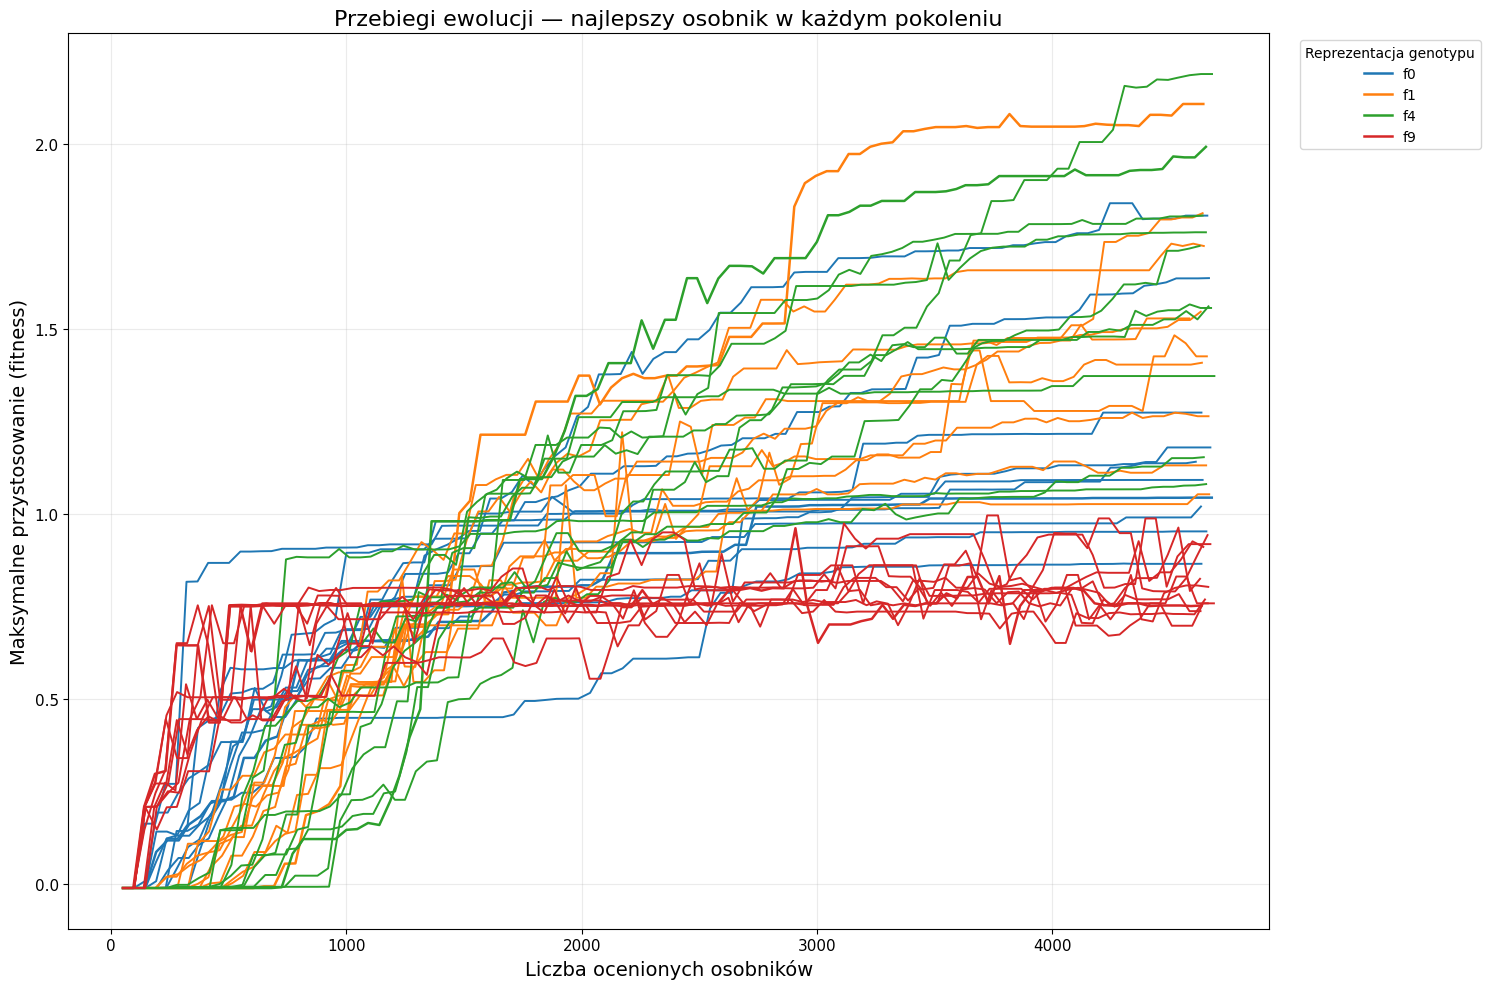

In [6]:
df = pd.DataFrame(all_data)
df["cumulative_nevals"] = df.groupby(["genotype_format", "iteration"])["nevals"].cumsum()
results_csv = log_dir / "genotype_results.csv"
df.to_csv(results_csv, index=False)

df_times = pd.DataFrame(times_data)
times_csv = log_dir / "genotype_times.csv"
df_times.to_csv(times_csv, index=False)

df = pd.read_csv(results_csv)

plt.figure(figsize=(15, 10), dpi=100)
genotypes = sorted(df["genotype_format"].unique())
palette = sns.color_palette("tab10")[:len(genotypes)]

for genotype, color in zip(genotypes, palette):
    iters = sorted(df[df["genotype_format"] == genotype]["iteration"].unique())
    for iteration in iters:
        df_temp = df[
            (df["genotype_format"] == genotype) & 
            (df["iteration"] == iteration)
        ].sort_values("cumulative_nevals")
        if df_temp.empty:
            continue

        plt.plot(
            df_temp["cumulative_nevals"], 
            df_temp["max"],
            label=f"{genotype}" if iteration == iters[0] else None,
            color=color,
            linewidth=1.8 if iteration == iters[0] else 1.4,
            alpha=1.0
        )

plt.title("Przebiegi ewolucji — najlepszy osobnik w każdym pokoleniu", fontsize=16)
plt.xlabel("Liczba ocenionych osobników", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Reprezentacja genotypu", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji.png", dpi=200)
plt.show()

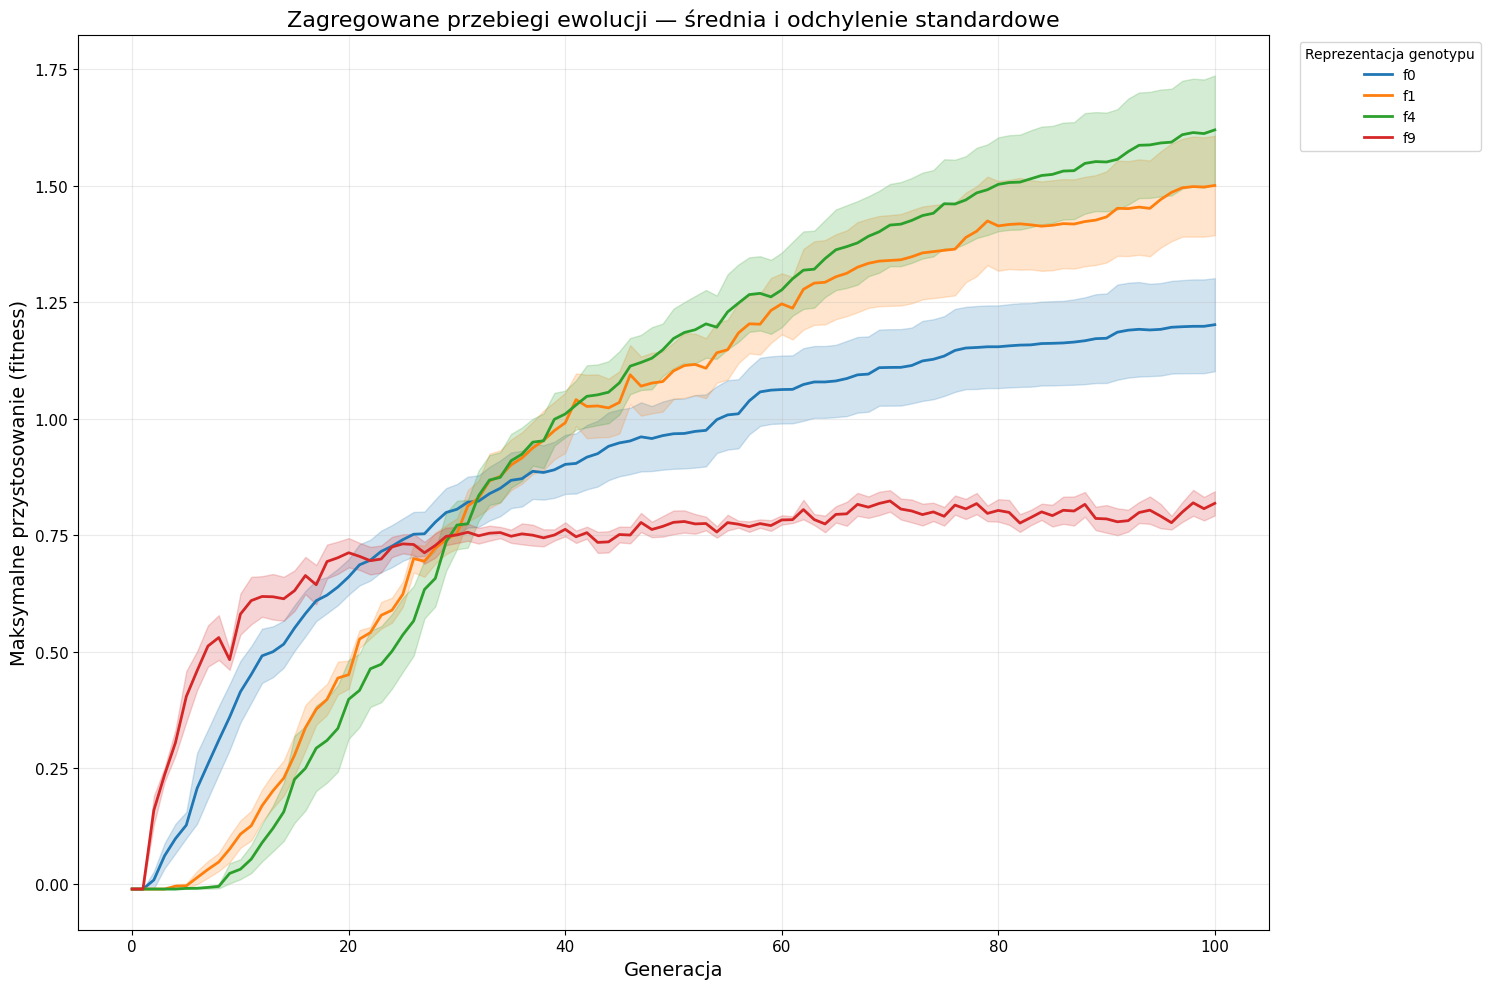

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
log_dir = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes" / "evolution_logs"

results_csv = log_dir / "genotype_results.csv"
df = pd.read_csv(results_csv)

df_agg = df.groupby(["gen", "genotype_format"])["max"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(15, 10), dpi=100)
genotypes = sorted(df_agg["genotype_format"].unique())
palette = sns.color_palette("tab10")[:len(genotypes)]
SCALING_FACTOR = 3

for genotype, color in zip(genotypes, palette):
    df_temp = df_agg[df_agg["genotype_format"] == genotype]
    if df_temp.empty:
        continue
    plt.plot(df_temp["gen"], df_temp["mean"], label=genotype, color=color, linewidth=2)
    plt.fill_between(
        df_temp["gen"],
        df_temp["mean"] - df_temp["std"] / SCALING_FACTOR,
        df_temp["mean"] + df_temp["std"] / SCALING_FACTOR,
        color=color,
        alpha=0.2
    )

plt.title("Zagregowane przebiegi ewolucji — średnia i odchylenie standardowe", fontsize=16)
plt.xlabel("Generacja", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Reprezentacja genotypu", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_zagregowane.png", dpi=200)
plt.show()


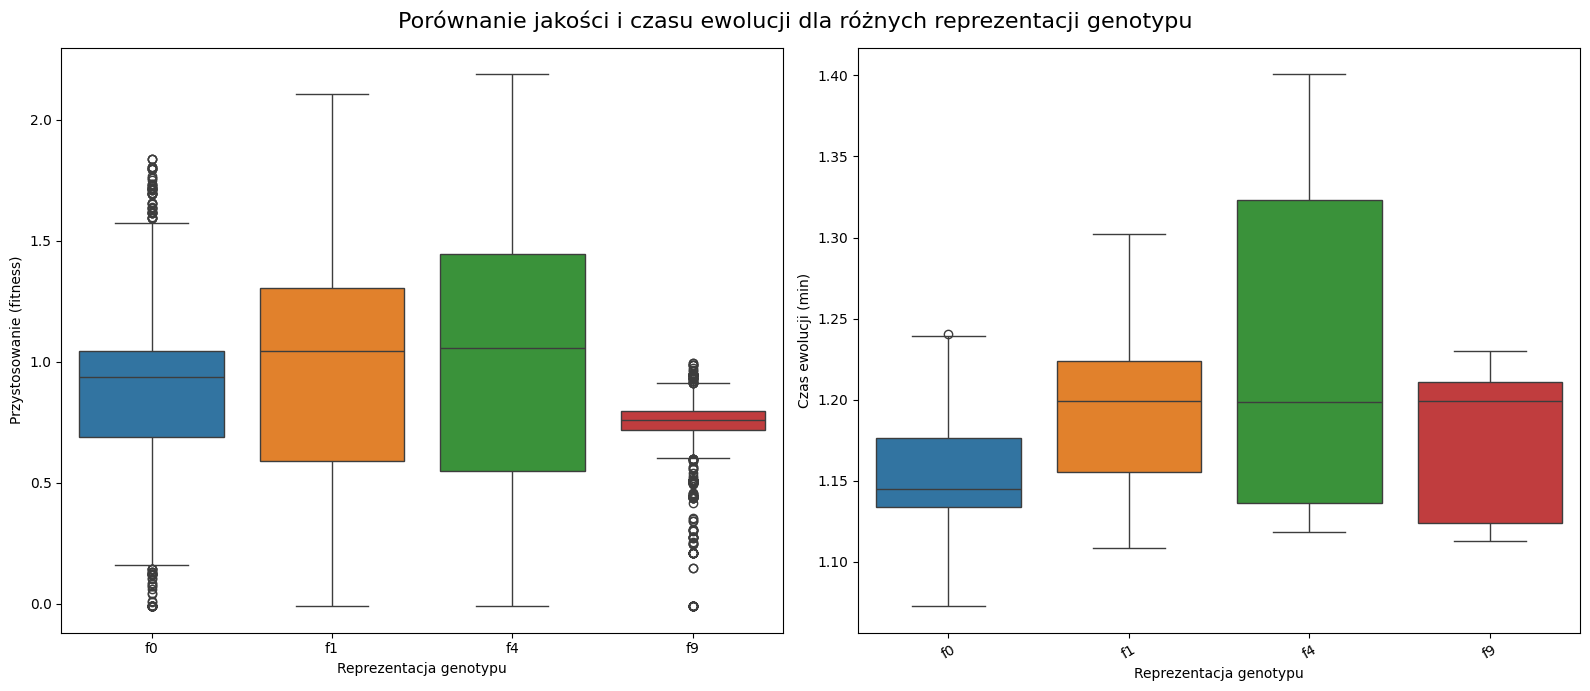

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
log_dir = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes" / "evolution_logs"

results_csv = log_dir / "genotype_results.csv"
times_csv = log_dir / "genotype_times.csv"

df = pd.read_csv(results_csv)
df_times = pd.read_csv(times_csv)

if "elapsed_time" in df_times.columns:
    df_times["elapsed_time"] /= 60

genotypes_sorted = sorted(df["genotype_format"].unique())
palette_colors = sns.color_palette("tab10")[:len(genotypes_sorted)]
palette = {g: color for g, color in zip(genotypes_sorted, palette_colors)}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

sns.boxplot(
    ax=axes[0],
    x="genotype_format",
    y="max",
    hue="genotype_format",
    data=df,
    palette=palette,
    dodge=False,
    legend=False
)
axes[0].set_xlabel("Reprezentacja genotypu")
axes[0].set_ylabel("Przystosowanie (fitness)")

if "elapsed_time" in df_times.columns:
    sns.boxplot(
        ax=axes[1],
        x="genotype_format",
        y="elapsed_time",
        hue="genotype_format",
        data=df_times,
        palette=palette,
        dodge=False,
        legend=False
    )
    axes[1].set_xlabel("Reprezentacja genotypu")
    axes[1].set_ylabel("Czas ewolucji (min)")
else:
    axes[1].set_visible(False)

plt.suptitle("Porównanie jakości i czasu ewolucji dla różnych reprezentacji genotypu", fontsize=16)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("przebiegi_ewolucji_boxploty.png", dpi=200)
plt.show()

Dla każdego z zapamiętanych rozwiązań-próbek (zapisuj ich genotypy i fitness) wygeneruj teraz pewną liczbę (co najmniej 20) jego mutantów-sąsiadów (każdy mutant ma tego samego rodzica-próbkę) i każdego z nich oceń. Odrzuć niepoprawne rozwiązania (o fitness=`FITNESS_VALUE_INFEASIBLE_SOLUTION`). Narysuj wykres punktowy, gdzie dla każdej próbki na osi X jest jej fitness, a na osi Y są fitnessy jej mutantów-sąsiadów. Taki wykres narysuj dla każdej z porównywanych reprezentacji dodając linię y=x. Wyznacz, ile procent mutantów w danej reprezentacji było lepszych od swoich rodziców. Opisz wnioski. Co możesz powiedzieć o krajobrazie (przynajmniej w otoczeniu zgromadzonych próbek) i jakie są różnice między reprezentacjami?

In [9]:
import sys, os, csv
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
FramsticksLib_path = FRAMSPY_DIR
sys.path.insert(0, str(FramsticksLib_path))
from FramsticksLib import FramsticksLib
sys.path.pop(0)

LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
LIB_NAME = "frams-objects.dll"
SIM_FILES = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"

PARENTS_BASE = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes"
OUTPUT_BASE = FRAMSPY_DIR / "results" / "landscape" / "mutants"
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

genformats = [0, 1, 4, 9]
MUTANTS_PER_PARENT = 20
FITNESS_INFEASIBLE = -999999.0

def read_genotype(file_path):
    lines = file_path.read_text(encoding="utf-8").splitlines()
    genotype_lines = []
    reading = False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"):
            continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~":
                genotype_lines.append(val.replace("~", ""))
            continue
        if reading:
            if line.startswith("vertpos:"):
                break
            if line != "~":
                genotype_lines.append(line.replace("~", ""))
    return "\n".join(genotype_lines).strip()

def frams_evaluate(frams_lib, genotype):
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            data = frams_lib.evaluate([genotype])
            return data[0]["evaluations"][""]["vertpos"]
        except:
            return FITNESS_INFEASIBLE
        finally:
            sys.stdout, sys.stderr = old_out, old_err

def frams_mutate(frams_lib, genotype):
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            mutated = frams_lib.mutate([genotype])[0]
            return mutated
        except:
            return None
        finally:
            sys.stdout, sys.stderr = old_out, old_err

for genformat in genformats:
    parents_dir = PARENTS_BASE / f"f{genformat}"
    parent_files = sorted(parents_dir.glob("starting_f*.gen"))
    if not parent_files:
        continue

    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            frams_lib = FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
        finally:
            sys.stdout, sys.stderr = old_out, old_err

    csv_path = OUTPUT_BASE / f"mutants_f{genformat}.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as fcsv:
        writer = csv.writer(fcsv)
        writer.writerow(["parent_fitness", "mutant_fitness"])

        for pf in parent_files:
            parent_genotype = read_genotype(pf)
            if not parent_genotype:
                continue

            parent_fitness = frams_evaluate(frams_lib, parent_genotype)
            if parent_fitness == FITNESS_INFEASIBLE:
                continue

            generated = 0
            while generated < MUTANTS_PER_PARENT:
                mutant_genotype = frams_mutate(frams_lib, parent_genotype)
                if not mutant_genotype:
                    continue

                mutant_fitness = frams_evaluate(frams_lib, mutant_genotype)
                if mutant_fitness == FITNESS_INFEASIBLE:
                    continue

                writer.writerow([parent_fitness, mutant_fitness])
                generated += 1

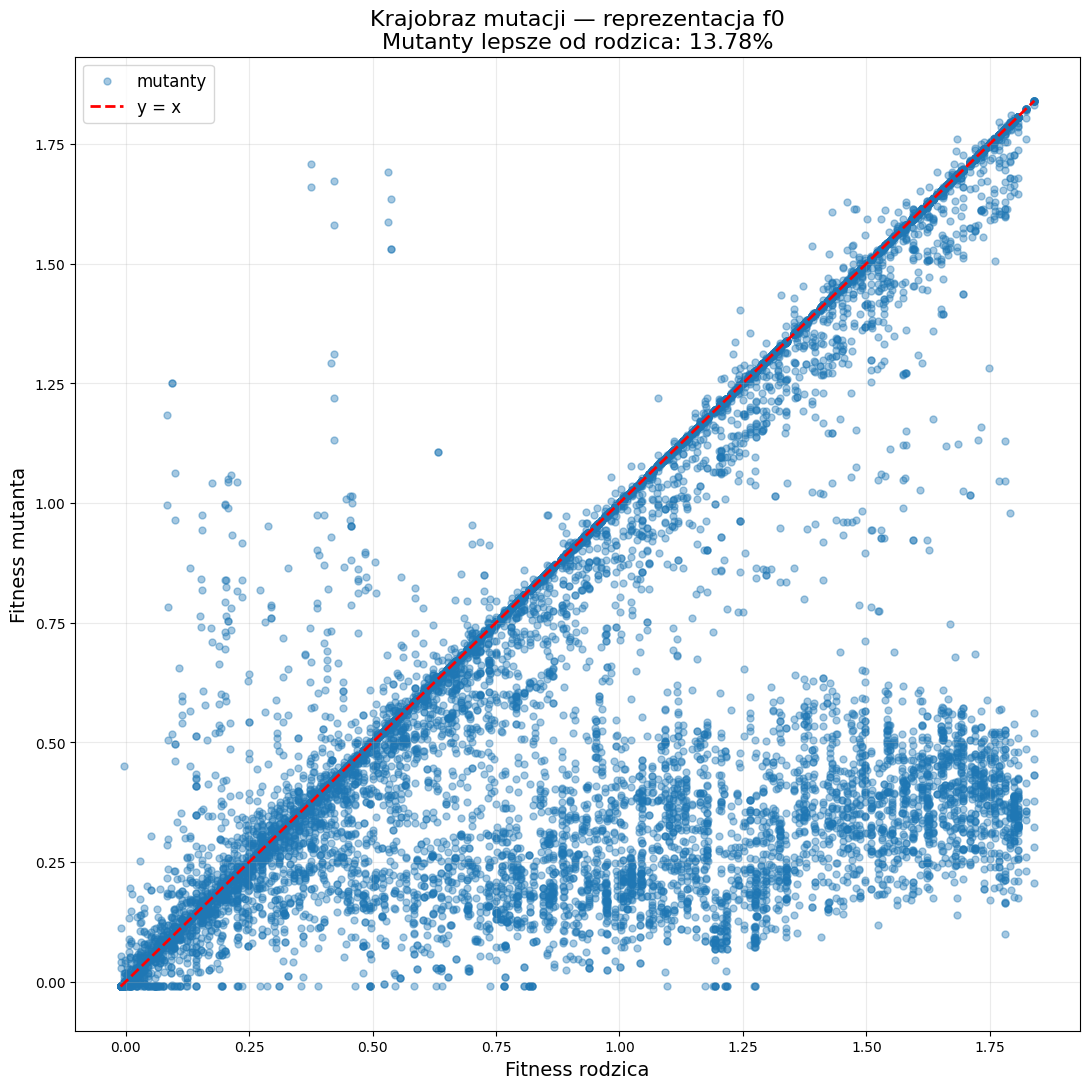

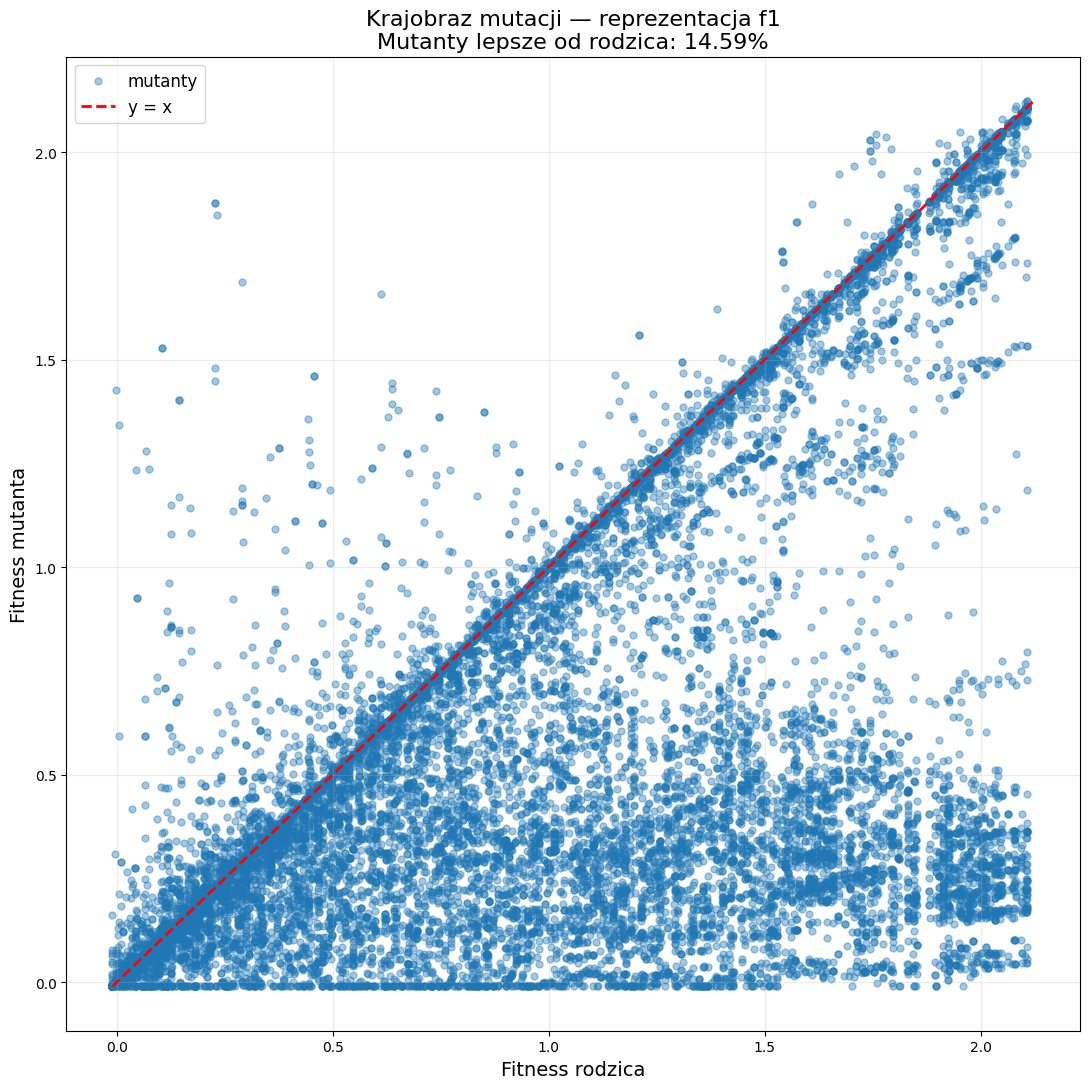

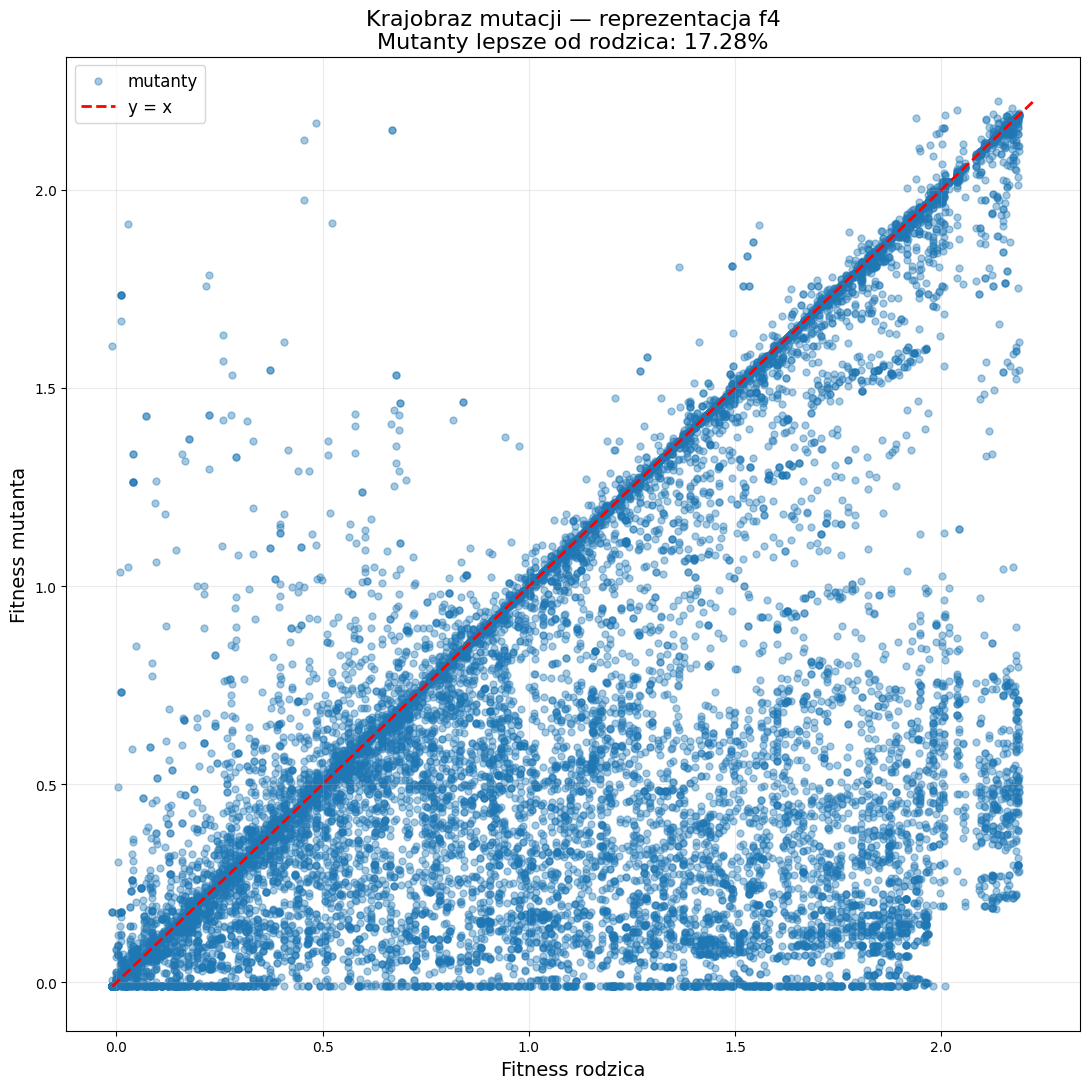

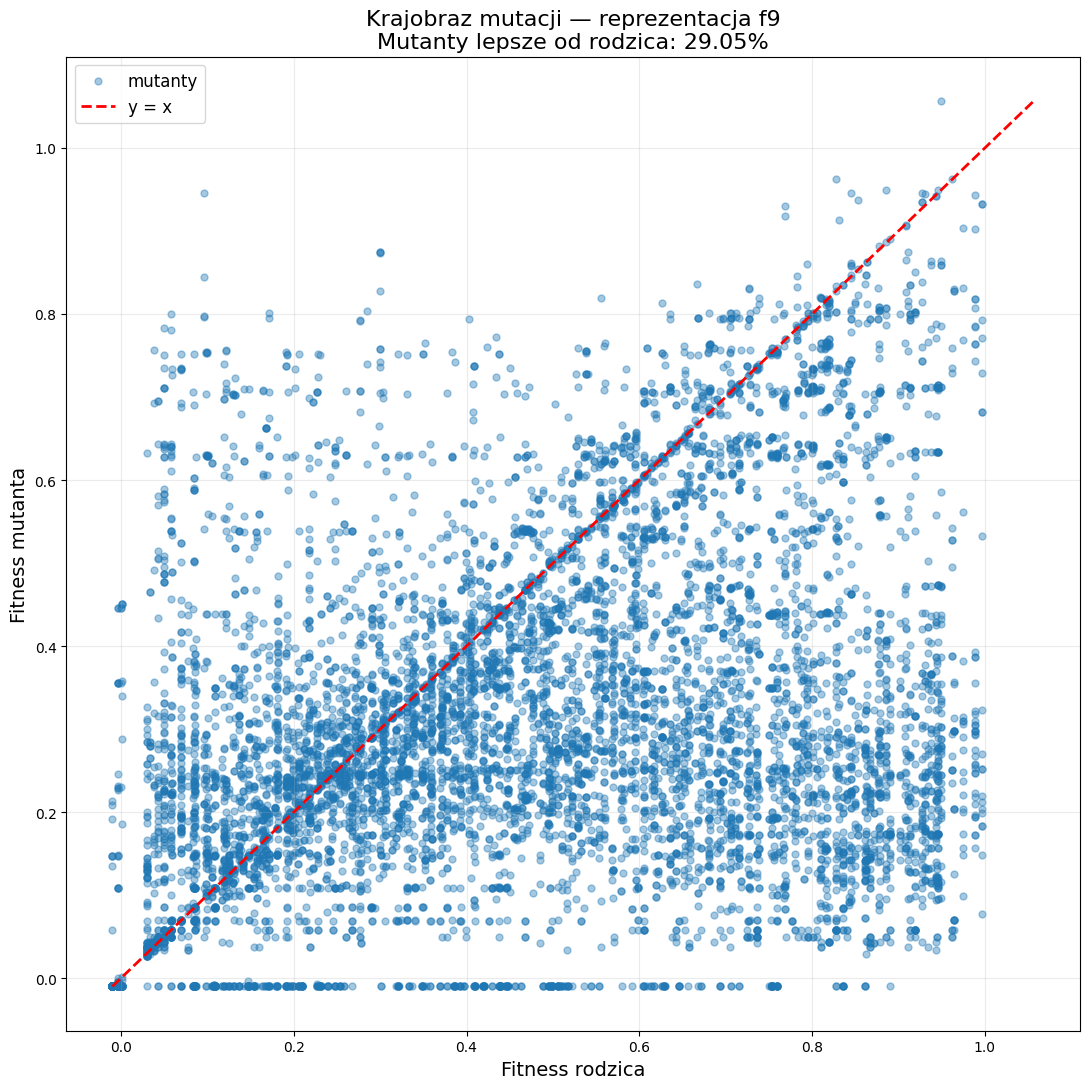

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
DATA_DIR = FRAMSPY_DIR / "results" / "landscape" / "mutants"
OUTPUT_DIR = Path.cwd()

genformats = [0, 1, 4, 9]

for genformat in genformats:
    csv_file = DATA_DIR / f"mutants_f{genformat}.csv"
    if not csv_file.exists():
        continue

    df = pd.read_csv(csv_file)
    if df.empty:
        continue

    parent_fitnesses = df["parent_fitness"].values
    mutant_fitnesses = df["mutant_fitness"].values

    better = (mutant_fitnesses > parent_fitnesses).sum()
    total = len(df)
    better_percent = 100.0 * better / total

    plt.figure(figsize=(11, 11))

    plt.scatter(
        parent_fitnesses,
        mutant_fitnesses,
        alpha=0.4,
        s=25,
        label="mutanty"
    )

    line_min = min(parent_fitnesses.min(), mutant_fitnesses.min())
    line_max = max(parent_fitnesses.max(), mutant_fitnesses.max())

    plt.plot(
        [line_min, line_max],
        [line_min, line_max],
        "r--",
        linewidth=2,
        label="y = x"
    )

    plt.title(
        f"Krajobraz mutacji — reprezentacja f{genformat}\n"
        f"Mutanty lepsze od rodzica: {better_percent:.2f}%",
        fontsize=16
    )
    plt.xlabel("Fitness rodzica", fontsize=14)
    plt.ylabel("Fitness mutanta", fontsize=14)

    plt.grid(alpha=0.25)
    plt.legend(fontsize=12)
    plt.tight_layout()

    filename = OUTPUT_DIR / f"fitness_mutantow_f{genformat}.png"
    plt.savefig(filename, dpi=200)
    plt.show()

- Wybrany problem optymalizacyjny: vertpos
- Metoda generowania osobników: szybkie zachłanne ewolucje

Dla wszystkich analizowanych reprezentacji wykresy punktowe fitnessu rodzica względem fitnessu jego mutantów wskazują na wyraźnie chropowaty charakter krajobrazu przystosowania w otoczeniu zgromadzonych próbek. Występują liczne przypadki, w których niewielka mutacja prowadzi do istotnego spadku jakości rozwiązania, często aż do bardzo niskich wartości fitness. Jednocześnie widoczne jest silne zagęszczenie punktów w pobliżu linii y = x, co oznacza, że duża część mutacji nie zmienia istotnie przystosowania i odpowiada lokalnym płaskowyżom krajobrazu.

Poprawa jakości potomków pojawia się głównie w otoczeniu bardzo słabych rozwiązań, natomiast w rejonach wysokiego fitnessu mutacje rzadko prowadzą do dalszego wzrostu jakości, co sugeruje obecność lokalnych optimów oraz ograniczoną gładkość krajobrazu. Zaobserwowane udziały mutantów lepszych od swoich rodziców wyniosły:

- **f0:** 13.78%  
- **f1:** 14.59%  
- **f4:** 17.28%  
- **f9:** 29.05%

Reprezentacje **f0**, **f1** i **f4** charakteryzują się względnie podobnym poziomem chropowatości, przy czym **f4** wykazuje największy odsetek korzystnych mutacji spośród nich, co jest spójne z najlepszymi wynikami osiąganymi przez tę reprezentację w samej ewolucji. Wskazuje to na bardziej użyteczną lokalną strukturę krajobrazu, mimo że nadal dominuje w nim duża liczba mutacji pogarszających rozwiązania.

Reprezentacja **f9** wyróżnia się najwyższym odsetkiem mutantów lepszych od rodzica, jednak poprawy te mają w dużej mierze charakter losowy i dotyczą głównie bardzo słabych osobników. Jednocześnie widoczne są „przerwy” w rozkładzie osiąganych wartości fitness – niektóre poziomy przystosowania są trudne do uzyskania, a mutacje często powodują skoki do znacznie gorszych obszarów krajobrazu. Sugeruje to krajobraz silnie nieciągły i nieregularny, co tłumaczy słabe wyniki globalnej optymalizacji w tej reprezentacji mimo pozornie wysokiego udziału korzystnych mutacji.

### Zadanie 2

Skoro mamy już różnorodne rozwiązania-próbki, spróbuj analogiczny wykres skonstruować dla krzyżowania. Krzyżuj pary wybranych rodziców i oceniaj potomków. Odrzuć niepoprawnych potomków (o fitness=`FITNESS_VALUE_INFEASIBLE_SOLUTION`). Chcemy dzięki temu wykresowi odpowiedzieć na pytanie, jak fitness potomka ma się do fitnessu rodziców oraz dla jakich rozwiązań (o jakim fitness) krzyżowanie jest korzystne, a dla jakich nie. Wymyśl adekwatny sposób wizualizacji tej zależności – może 3D zapisywalny jako samowystarczalny html, a może lepszy będzie odpowiednio skonstruowany 2D. Kolejność rodziców nie ma znaczenia.

Podobnie jak w poprzednim pytaniu, będziesz miał(a) tyle wykresów, ile porównywanych reprezentacji genetycznych. Zaproponuj i oblicz przynajmniej jedną statystykę (formułę), która na podstawie zgromadzonych tu informacji dotyczących danej reprezentacji wyznaczy pojedynczą liczbę odzwierciedlającą istotną cechę krzyżowania w tej reprezentacji. Opisz wnioski.

In [11]:
import sys, os, csv, random
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
FramsticksLib_path = FRAMSPY_DIR
sys.path.insert(0, str(FramsticksLib_path))
from FramsticksLib import FramsticksLib
sys.path.pop(0)

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
LIB_NAME = "frams-objects.dll"
SIM_FILES = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"

OUTPUT_DIR = FRAMSPY_DIR / "results" / "landscape" / "xover"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

genformats = [0, 1, 4, 9]
FITNESS_VALUE_INFEASIBLE_SOLUTION = -999999.0
NUM_BUCKETS = 50
SAMPLES_PER_BUCKET = 5

def read_genotype(file_path):
    lines = file_path.read_text(encoding="utf-8").splitlines()
    genotype_lines = []
    reading = False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"):
            continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~":
                genotype_lines.append(val.replace("~",""))
            continue
        if reading:
            if line.startswith("vertpos:"):
                break
            if line == "~":
                continue
            genotype_lines.append(line.replace("~",""))
    return "\n".join(l for l in genotype_lines if l).strip()

def frams_evaluate(frams_lib, individual):
    genotype = individual[0]
    FITNESS_CRITERIA_INFEASIBLE_SOLUTION = [FITNESS_VALUE_INFEASIBLE_SOLUTION]
    with open(os.devnull, 'w') as fnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = fnull, fnull
        try:
            data = frams_lib.evaluate([genotype])
            fitness = [data[0]["evaluations"][""]["vertpos"]]
        except:
            fitness = FITNESS_CRITERIA_INFEASIBLE_SOLUTION
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr
    return fitness

def frams_crossover(frams_lib, parent1, parent2):
    f1 = frams_evaluate(frams_lib, parent1)[0]
    f2 = frams_evaluate(frams_lib, parent2)[0]

    with open(os.devnull, 'w') as fnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = fnull, fnull
        try:
            child1 = [frams_lib.crossOver(parent1[0], parent2[0])]
            child2 = [frams_lib.crossOver(parent1[0], parent2[0])]
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

    f3 = frams_evaluate(frams_lib, child1)[0]
    f4 = frams_evaluate(frams_lib, child2)[0]

    return f1, f2, f3, f4

for genformat in genformats:
    parents_dir = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes" / f"f{genformat}"
    parent_files = sorted(parents_dir.glob("starting_f*.gen"))
    max_idx = len(parent_files) - 1
    if max_idx < 1:
        continue

    with open(os.devnull, 'w') as fnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = fnull, fnull
        try:
            frams_lib = FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr

    parent_fitness_list = []
    for pf in parent_files:
        geno = [read_genotype(pf)]
        f = frams_evaluate(frams_lib, geno)[0]
        parent_fitness_list.append(f)

    minf = min(parent_fitness_list)
    maxf = max(parent_fitness_list)
    bucket_size = (maxf - minf) / NUM_BUCKETS
    buckets = [[] for _ in range(NUM_BUCKETS)]
    for idx, f in enumerate(parent_fitness_list):
        b = int((f - minf) / bucket_size)
        if b >= NUM_BUCKETS:
            b = NUM_BUCKETS - 1
        buckets[b].append(idx)

    csv_file = OUTPUT_DIR / f"xover_buckets_f{genformat}.csv"
    with open(csv_file, 'w', newline='', encoding='utf-8') as fcsv:
        writer = csv.writer(fcsv)
        writer.writerow(["Bucket1", "Bucket2", "Mean_children_fitness"])

        for i in range(NUM_BUCKETS):
            for j in range(NUM_BUCKETS):
                if not buckets[i] or not buckets[j]:
                    continue
                selected_i = random.choices(buckets[i], k=min(SAMPLES_PER_BUCKET, len(buckets[i])))
                selected_j = random.choices(buckets[j], k=min(SAMPLES_PER_BUCKET, len(buckets[j])))
                children_fitness = []
                for idx1 in selected_i:
                    for idx2 in selected_j:
                        p1 = [read_genotype(parent_files[idx1])]
                        p2 = [read_genotype(parent_files[idx2])]
                        f1, f2, f3, f4 = frams_crossover(frams_lib, p1, p2)
                        if f3 != FITNESS_VALUE_INFEASIBLE_SOLUTION:
                            children_fitness.append(f3)
                        if f4 != FITNESS_VALUE_INFEASIBLE_SOLUTION:
                            children_fitness.append(f4)
                if children_fitness:
                    mean_fitness = sum(children_fitness) / len(children_fitness)
                    writer.writerow([i, j, mean_fitness])
                    fcsv.flush()

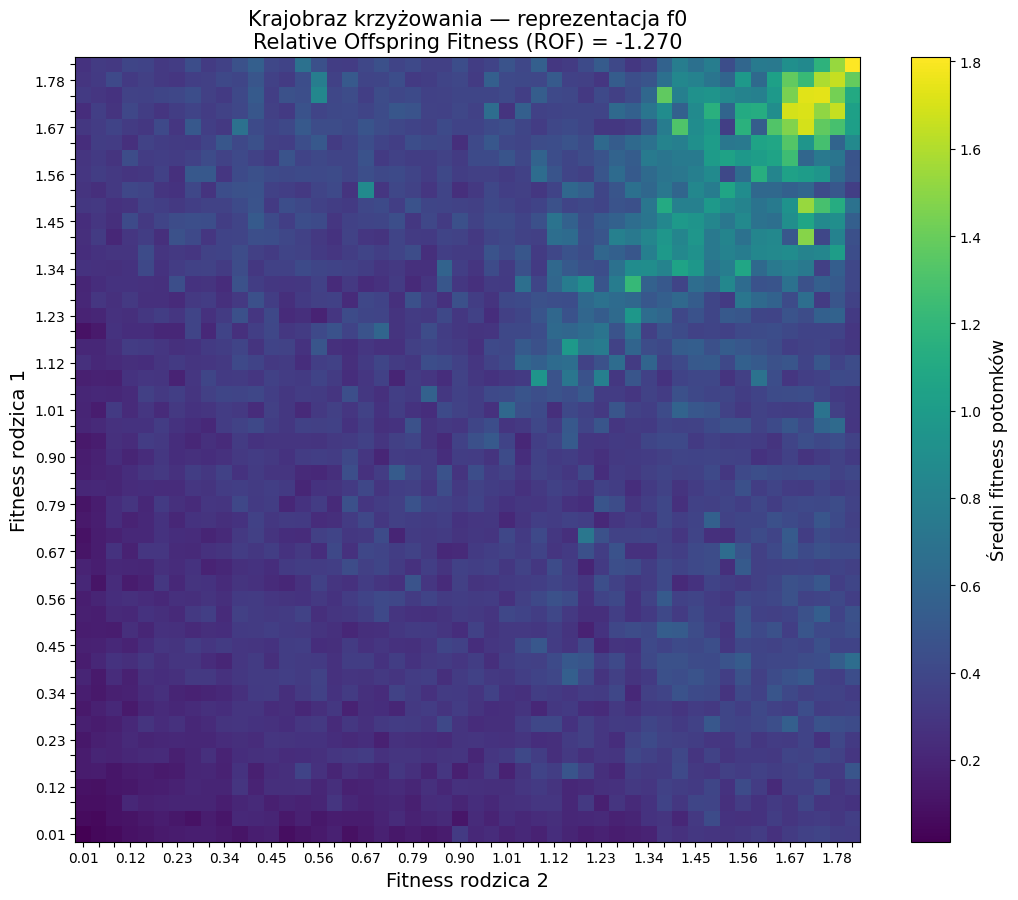

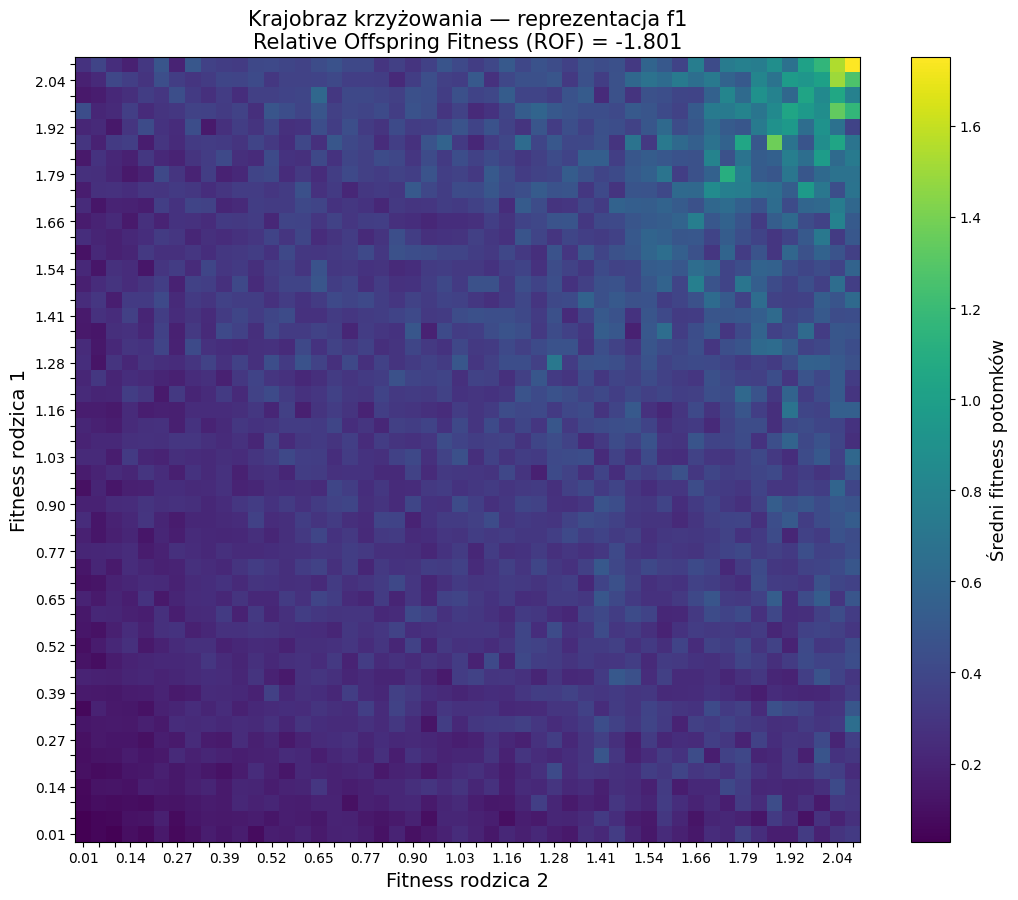

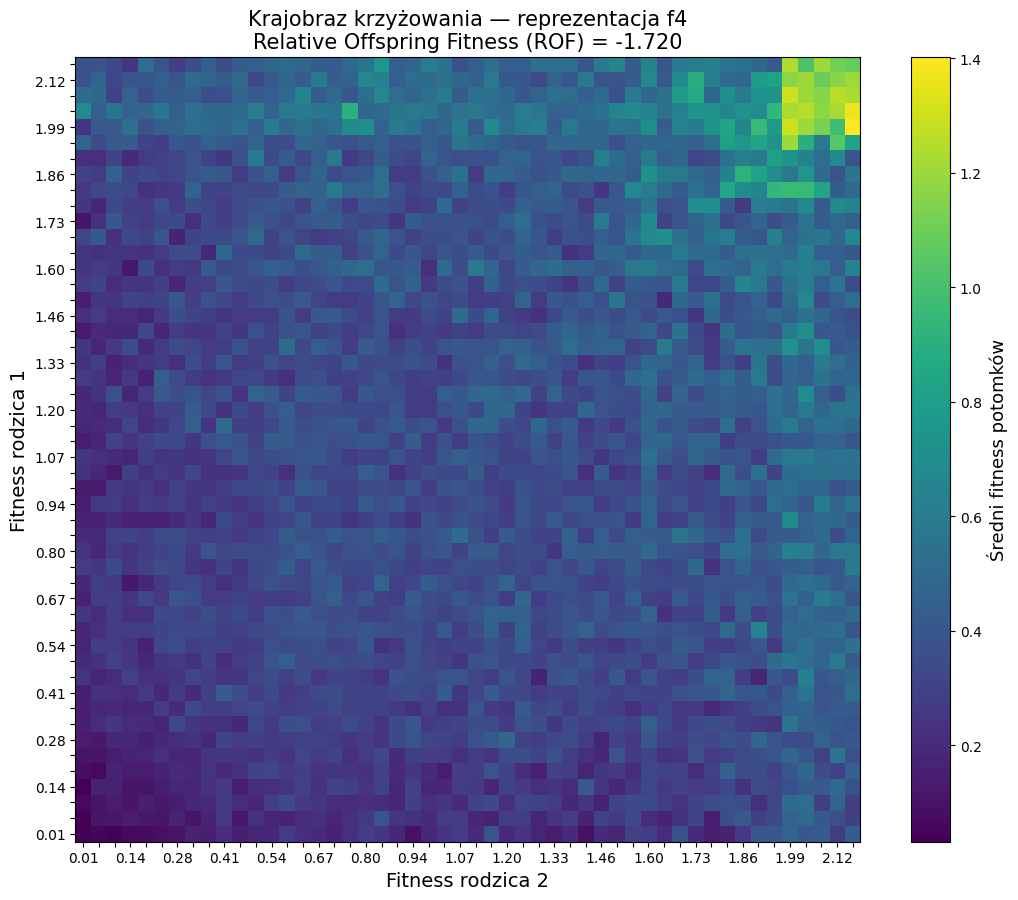

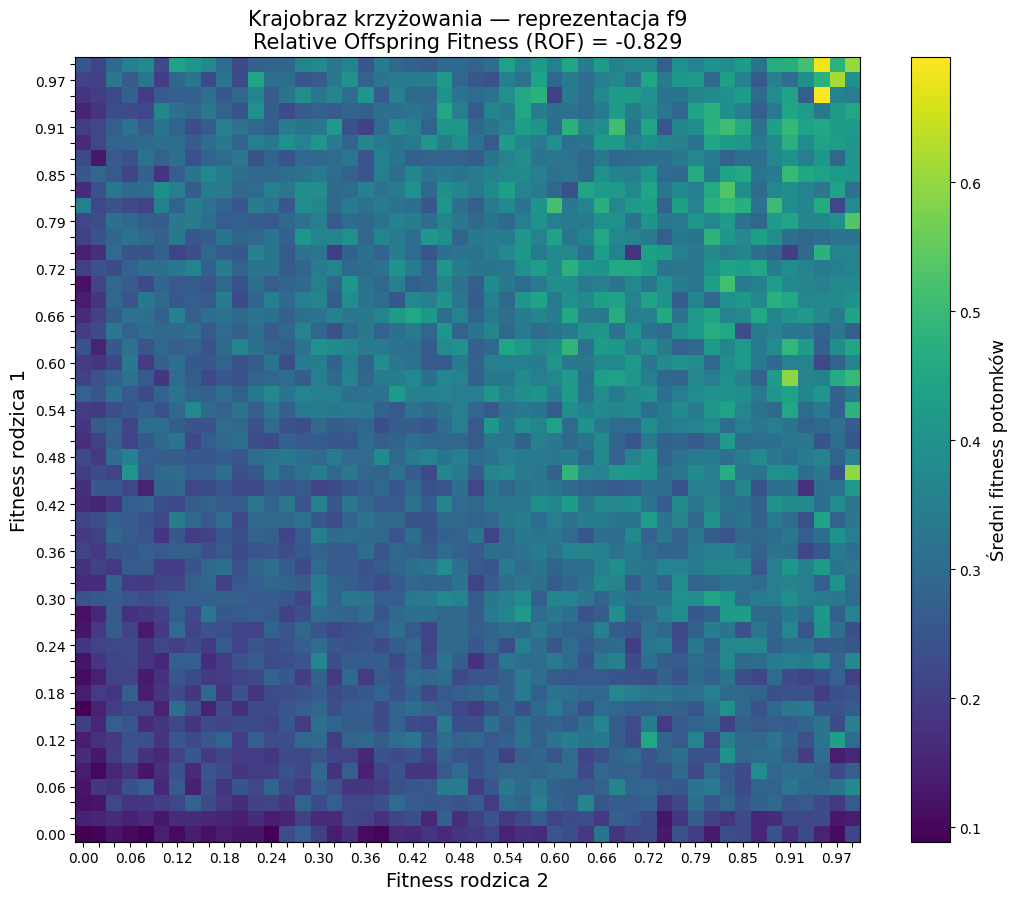

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.ticker import MaxNLocator

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
XOVER_DIR = FRAMSPY_DIR / "results" / "landscape" / "xover"
PARENTS_DIR_BASE = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes"

OUTPUT_DIR = Path.cwd()
genformats = [0, 1, 4, 9]
NUM_BUCKETS = 50
TICK_STEP = 3

def read_parent_fitnesses(genformat):
    parents_dir = PARENTS_DIR_BASE / f"f{genformat}"
    parent_files = sorted(parents_dir.glob("starting_f*.gen"))

    fitnesses = []
    for pf in parent_files:
        for line in pf.read_text(encoding="utf-8").splitlines():
            if line.startswith("vertpos:"):
                fitnesses.append(float(line[len("vertpos:"):].strip()))
                break
    return fitnesses

for genformat in genformats:
    csv_file = XOVER_DIR / f"xover_buckets_f{genformat}.csv"
    if not csv_file.exists():
        continue

    df = pd.read_csv(csv_file)
    parent_fitnesses = read_parent_fitnesses(genformat)
    if not parent_fitnesses:
        continue

    minf = min(parent_fitnesses)
    maxf = max(parent_fitnesses)
    bucket_size = (maxf - minf) / NUM_BUCKETS

    bucket_centers = [
        minf + (i + 0.5) * bucket_size
        for i in range(NUM_BUCKETS)
    ]

    heatmap = np.full((NUM_BUCKETS, NUM_BUCKETS), np.nan)
    for _, row in df.iterrows():
        i = int(row["Bucket1"])
        j = int(row["Bucket2"])
        heatmap[i, j] = row["Mean_children_fitness"]

    rof_values = []

    for i in range(NUM_BUCKETS):
        for j in range(NUM_BUCKETS):
            f_child = heatmap[i, j]
            if np.isnan(f_child):
                continue

            f1 = bucket_centers[i]
            f2 = bucket_centers[j]

            f_low = min(f1, f2)
            f_high = max(f1, f2)

            if f_high != f_low:
                rof = (f_child - f_low) / (f_high - f_low)
                rof_values.append(rof)

    mean_rof = np.mean(rof_values) if rof_values else np.nan

    fig, ax = plt.subplots(figsize=(11, 9))

    im = ax.imshow(
        heatmap,
        origin="lower",
        cmap="viridis",
        interpolation="nearest"
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Średni fitness potomków", fontsize=13)

    ticks = range(0, NUM_BUCKETS, TICK_STEP)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xticklabels([f"{bucket_centers[i]:.2f}" for i in ticks])
    ax.set_yticklabels([f"{bucket_centers[i]:.2f}" for i in ticks])

    ax.set_xlabel("Fitness rodzica 2", fontsize=14)
    ax.set_ylabel("Fitness rodzica 1", fontsize=14)

    ax.set_title(
        f"Krajobraz krzyżowania — reprezentacja f{genformat}\n"
        f"Relative Offspring Fitness (ROF) = {mean_rof:.3f}",
        fontsize=15
    )

    ax.xaxis.set_major_locator(MaxNLocator(NUM_BUCKETS))
    ax.yaxis.set_major_locator(MaxNLocator(NUM_BUCKETS))

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fitness_xoverow_f{genformat}.png", dpi=200)
    plt.show()

Do analizy operatora krzyżowania wykorzystano dwuwymiarowe mapy cieplne, w których osie odpowiadają fitnessom obojga rodziców. Teoretycznie kolejność rodziców nie ma znaczenia, jednak w praktyce zaobserwowano różnice pomiędzy wynikami `cross(p1, p2)` i `cross(p2, p1)`, co stanowi dodatkowy sygnał dużej chropowatości krajobrazu przystosowania oraz niestabilności lokalnych zależności pomiędzy genotypem a fitnessem.

Kolor mapy ciepła przedstawia średni fitness potomków uzyskanych z par rodziców należących do danych przedziałów jakości. Wizualizacja ta pozwala ocenić, dla jakich kombinacji fitnessów rodziców krzyżowanie jest względnie korzystne, a dla jakich prowadzi do degradacji jakości. We wszystkich reprezentacjach dominują obszary o niskich wartościach fitness potomków, co wskazuje, że krzyżowanie rzadko generuje rozwiązania lepsze od rodziców, a krajobraz w ich otoczeniu jest wyraźnie chropowaty.

Dodatkowo zaproponowano miarę **Relative Offspring Fitness (ROF)**, która opisuje, jak bardzo średni fitness potomków przypomina fitness lepszego rodzica w relacji do gorszego, w postaci liniowej interpolacji pomiędzy oboma rodzicami. Wartość 0 oznacza potomstwo porównywalne z gorszym rodzicem, 1 – z lepszym, wartości ujemne wskazują na potomków gorszych niż słabszy rodzic. Ujemne wartości tej miary są zatem naturalne i świadczą o destrukcyjnym charakterze krzyżowania w danym krajobrazie.

Uzyskane wartości ROF wyniosły:
- **f0:** −1.270  
- **f1:** −1.801  
- **f4:** −1.720  
- **f9:** −0.829  

Dla reprezentacji **f0** najwyższe wartości fitness potomków koncentrują się głównie w pobliżu przekątnej mapy ciepła, co sugeruje, że krzyżowanie osobników o podobnej jakości jest najmniej destrukcyjne, natomiast łączenie bardzo dobrych osobników ze słabymi zwykle prowadzi do silnego spadku fitnessu potomstwa. W reprezentacjach **f1** i **f4** obserwuje się jeszcze bardziej ujemne wartości ROF, co oznacza, że przeciętnie krzyżowanie silniej degraduje jakość rozwiązań, mimo że lokalnie widoczne są obszary umożliwiające sensowną wymianę informacji genetycznej między osobnikami o bardzo różnych fitnessach. Reprezentacja **f9** charakteryzuje się najmniej ujemną wartością ROF, lecz jednocześnie wykazuje dużą ziarnistość mapy ciepła oraz wyraźne „luki” w osiągalnych wartościach fitnessu, co wskazuje na istnienie obszarów krajobrazu trudnych do osiągnięcia i bardziej losowy charakter działania operatora krzyżowania.

### Zadanie 3

Na zakończenie przeprowadzimy jeszcze jedna analizę ujawniającą pewną cechę krajobrazu (i zarazem operatorów mutacji). Wybierz około 20 rozwiązań (od najlepszych znalezionych do najgorszych, o najniższym fitness) i dla każdego z nich wykonaj sekwencję np. 30-tu mutacji ("losowy spacer" – to ma być sekwencja!), oceniając każdego mutanta. Jeśli któryś mutant wypadnie niepoprawny (jego pseudo-ocena wyniesie `FITNESS_VALUE_INFEASIBLE_SOLUTION`), powtarzaj daną mutację do skutku (aż powstanie poprawny mutant).

Następnie narysuj zwykłe wykresy liniowe (na osi poziomej – numer mutanta w sekwencji zaczynając od oryginalnej próbki, na osi pionowej – wartości fitnessów). Dobierz kolory zależnie od jakości rozwiązań początkowych (na przykład 4 różne kolory dla grup po 5 rozwiązań: najlepsze 5 rozwiązań – 5 zielonych linii, kolejne 5 – niebieskie, kolejne 5 – pomarańczowe, najgorsze 5 – czerwone). Celem jest zobaczenie, jak na różnych poziomach fitnessu układają się losowe ścieżki wytworzone przez sukcesywne mutacje [dyskusja na zajęciach, rozwiązanie jako "pamięć"].

Zamieść wykresy, opisz jak je skonstruowałeś/aś i zinterpretuj uzyskane wyniki w kontekście krajobrazów przystosowania.

In [13]:
import sys, os, csv
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
FramsticksLib_path = FRAMSPY_DIR
sys.path.insert(0, str(FramsticksLib_path))
from FramsticksLib import FramsticksLib
sys.path.pop(0)

LIB_DIR = r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53"
LIB_NAME = "frams-objects.dll"
SIM_FILES = "eval-allcriteria.sim;deterministic.sim;sample-period-2.sim;only-body.sim"

PARENTS_BASE = FRAMSPY_DIR / "results" / "landscape" / "starting_genotypes"
OUTPUT_BASE = FRAMSPY_DIR / "results" / "landscape" / "randomWalk"
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

genformats = [0, 1, 4, 9]
FITNESS_INFEASIBLE = -999999.0
WALK_LENGTH = 30
NUM_START_POINTS = 20

def read_genotype(file_path):
    lines = file_path.read_text(encoding="utf-8").splitlines()
    g, reading = [], False
    for line in lines:
        line = line.strip()
        if not line or line.startswith("org:"):
            continue
        if line.startswith("genotype:"):
            reading = True
            val = line[len("genotype:"):].strip()
            if val and val != "~":
                g.append(val.replace("~", ""))
            continue
        if reading:
            if line.startswith("vertpos:"):
                break
            if line != "~":
                g.append(line.replace("~", ""))
    return "\n".join(g).strip()

def frams_evaluate(frams_lib, genotype):
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            data = frams_lib.evaluate([genotype])
            return data[0]["evaluations"][""]["vertpos"]
        except:
            return FITNESS_INFEASIBLE
        finally:
            sys.stdout, sys.stderr = old_out, old_err

def frams_mutate(frams_lib, genotype):
    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            return frams_lib.mutate([genotype])[0]
        except:
            return None
        finally:
            sys.stdout, sys.stderr = old_out, old_err

for genformat in genformats:
    parents_dir = PARENTS_BASE / f"f{genformat}"
    parent_files = sorted(parents_dir.glob("starting_f*.gen"))
    if not parent_files:
        continue

    with open(os.devnull, "w") as fnull:
        old_out, old_err = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = fnull
        try:
            frams_lib = FramsticksLib(LIB_DIR, LIB_NAME, SIM_FILES)
        finally:
            sys.stdout, sys.stderr = old_out, old_err

    evaluated = []
    for pf in parent_files:
        g = read_genotype(pf)
        if not g:
            continue
        f = frams_evaluate(frams_lib, g)
        if f != FITNESS_INFEASIBLE:
            evaluated.append((f, g))

    evaluated.sort(key=lambda x: x[0])
    if len(evaluated) < NUM_START_POINTS:
        continue

    step = (len(evaluated) - 1) / (NUM_START_POINTS - 1)
    selected = [evaluated[int(i * step)] for i in range(NUM_START_POINTS)]

    csv_path = OUTPUT_BASE / f"randomwalk_f{genformat}.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as fcsv:
        writer = csv.writer(fcsv)
        writer.writerow(["start_id", "step", "fitness"])

        for sid, (start_fitness, start_genotype) in enumerate(selected):
            current_genotype = start_genotype
            current_fitness = start_fitness
            writer.writerow([sid, 0, current_fitness])

            for step_id in range(1, WALK_LENGTH + 1):
                while True:
                    mutant = frams_mutate(frams_lib, current_genotype)
                    if not mutant:
                        continue
                    f = frams_evaluate(frams_lib, mutant)
                    if f != FITNESS_INFEASIBLE:
                        current_genotype = mutant
                        current_fitness = f
                        writer.writerow([sid, step_id, f])
                        break


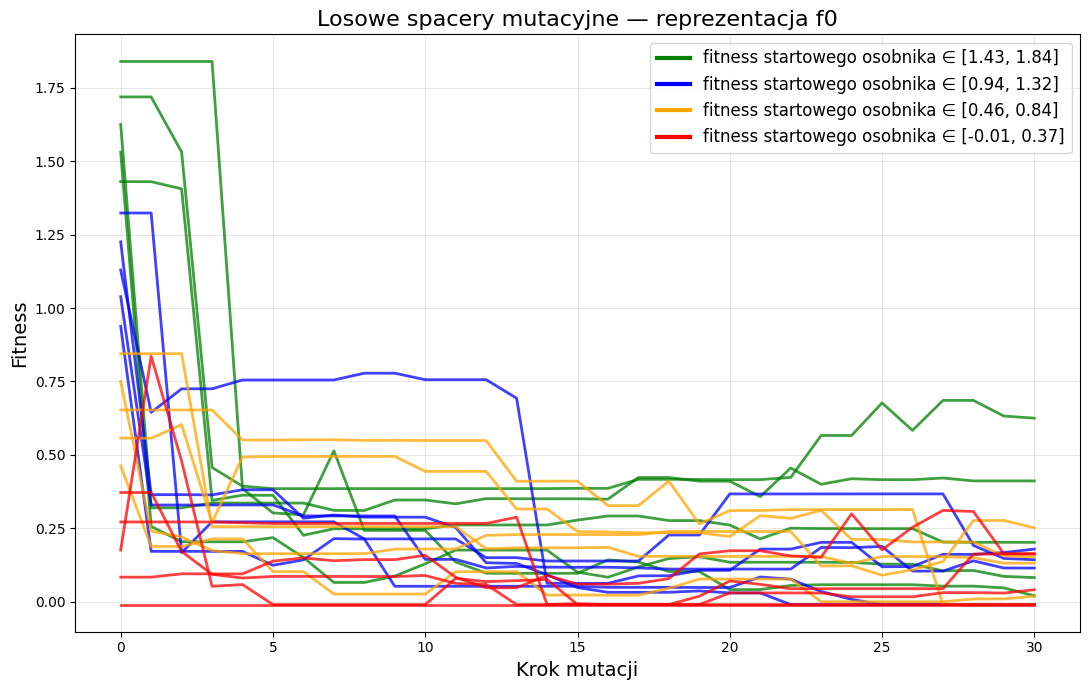

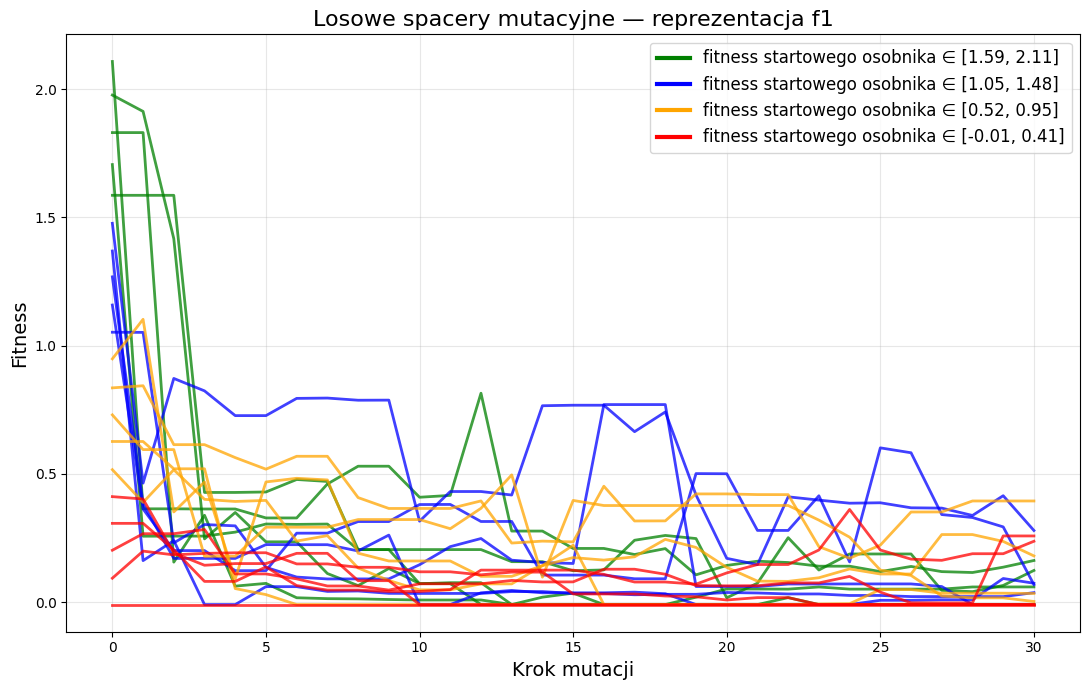

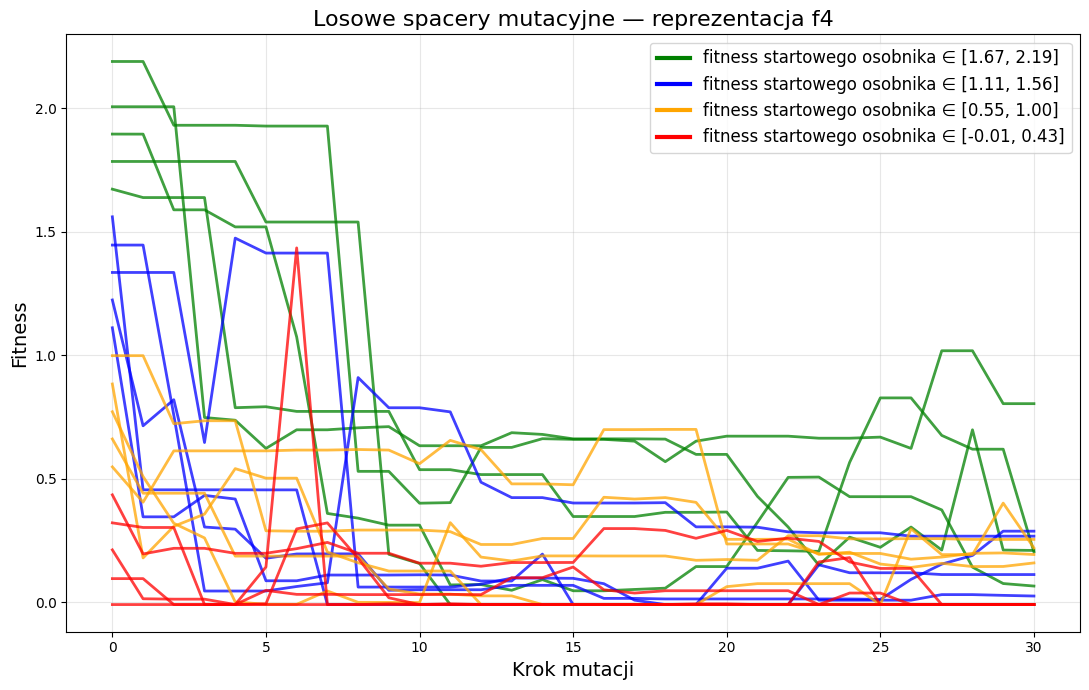

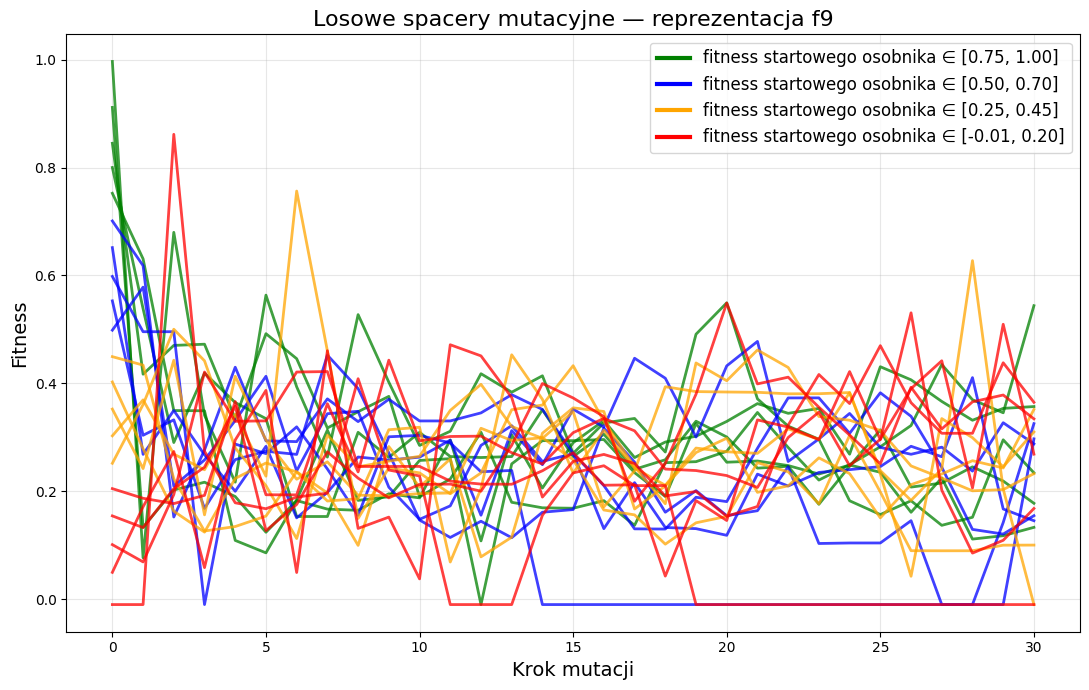

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import numpy as np

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
DATA_DIR = FRAMSPY_DIR / "results" / "landscape" / "randomWalk"
OUTPUT_DIR = Path.cwd()

genformats = [0, 1, 4, 9]

COLORS = ["green", "blue", "orange", "red"]

for genformat in genformats:
    csv_file = DATA_DIR / f"randomwalk_f{genformat}.csv"
    if not csv_file.exists():
        continue

    df = pd.read_csv(csv_file)
    if df.empty:
        continue

    start_fitness = (
        df[df["step"] == 0]
        .set_index("start_id")["fitness"]
        .sort_values(ascending=False)
    )

    start_ids_sorted = start_fitness.index.to_list()
    groups = np.array_split(start_ids_sorted, 4)

    plt.figure(figsize=(11, 7))
    legend_elements = []

    for group_idx, group_ids in enumerate(groups):
        color = COLORS[group_idx]

        f_min = start_fitness[group_ids].min()
        f_max = start_fitness[group_ids].max()

        legend_elements.append(
            Line2D(
                [0], [0],
                color=color,
                lw=3,
                label=f"fitness startowego osobnika ∈ [{f_min:.2f}, {f_max:.2f}]"
            )
        )

        for sid in group_ids:
            sub = df[df["start_id"] == sid]
            plt.plot(
                sub["step"],
                sub["fitness"],
                color=color,
                alpha=0.75,
                linewidth=2
            )

    plt.title(
        f"Losowe spacery mutacyjne — reprezentacja f{genformat}",
        fontsize=16
    )
    plt.xlabel("Krok mutacji", fontsize=14)
    plt.ylabel("Fitness", fontsize=14)

    plt.legend(
        handles=legend_elements,
        fontsize=12,
        frameon=True
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()

    filename = OUTPUT_DIR / f"fitness_losowych_spacerow_f{genformat}.png"
    plt.savefig(filename, dpi=200)
    plt.show()

Dla reprezentacji **f0**, **f1** oraz **f4** zaobserwowano, że losowy spacer oparty na mutacjach prowadzi średnio do pogarszania wartości fitnessu wraz z kolejnymi krokami. Jednocześnie widoczny jest wyraźny efekt „pamięci” punktu startowego: ścieżki rozpoczynające się od lepszych rozwiązań przez dłuższy czas utrzymują relatywnie wyższy poziom fitnessu, mimo że trend pozostaje spadkowy, natomiast spacery startujące z gorszych punktów szybko stabilizują się na niskich wartościach. Największe różnice pomiędzy grupami jakości początkowej występują w reprezentacji **f4**, gdzie dobre osobniki są najbardziej odporne na degradację jakości – mutacje w ich otoczeniu powodują relatywnie niewielkie zmiany fitnessu. Wskazuje to na bardziej lokalnie gładki krajobraz, przynajmniej w pobliżu dobrych rozwiązań.

Odmienny charakter ujawnia reprezentacja **f9**. W tym przypadku przebiegi fitnessu mają wyraźnie chaotyczny charakter: ścieżki szybko tracą związek z jakością rozwiązania początkowego, a losowe spacery wyglądają podobnie niezależnie od tego, czy startowały z osobników dobrych czy słabych. Sugeruje to bardzo chropowaty i niestabilny krajobraz przystosowania, w którym pojedyncze mutacje mogą prowadzić do dużych i trudnych do przewidzenia zmian jakości rozwiązania, a lokalna informacja o fitnessie nie niesie silnej wskazówki co do dalszego kierunku poprawy.


### Zadanie 4

Podsumowując konkluzje z przeprowadzonych analiz krajobrazu dla różnych reprezentacji genetycznych (różnych topologii przeszukiwania) – czy widzisz związki lub korelacje kształtu krajobrazu ze skutecznością ewolucji (tzn. z wykresami z pytania 1)?

Na tym laboratorium poznaliśmy sposoby badania i wizualizacji chropowatości/gładkości krajobrazu przystosowania oraz charakterystyki operatorów mutacji i krzyżowania. A jak zbadał(a)byś własność globalnej wypukłości krajobrazu?

Na podstawie przeprowadzonych analiz widać wyraźny związek pomiędzy lokalnym kształtem krajobrazu przystosowania a skutecznością procesu ewolucyjnego obserwowaną w przebiegach optymalizacji z zadania 1. Reprezentacje **f1** oraz **f4**, które lokalnie wykazują chropowatość, ale jednocześnie zachowują pewną strukturę i „ciągłość” sąsiedztwa (mutacje i krzyżowanie nie niszczą całkowicie jakości rozwiązań), osiągały najlepsze i najbardziej stabilne wyniki ewolucyjne. Chropowatość tych krajobrazów nie eliminuje informacji o kierunku poprawy, dzięki czemu algorytm może skutecznie eksplorować przestrzeń i odnajdywać dobre optima lokalne, które z czasem przekładają się na wysoką jakość rozwiązań globalnych.

Reprezentacja **f0** charakteryzuje się relatywnie gładszym krajobrazem lokalnym, co potwierdzają zarówno wykresy sąsiedztwa mutantów, jak i losowe spacery. Taka gładkość powoduje jednak, że pojedyncze mutacje są słabe i rzadko prowadzą do wyraźnej poprawy, a skuteczna ewolucja wymaga kumulacji wielu specyficznych zmian. W konsekwencji tempo poprawy jest wolniejsze, a osiągane wyniki są gorsze niż dla **f1** i **f4**. Z kolei **f9** wykazuje skrajnie chropowaty i chaotyczny krajobraz: zarówno mutacje, jak i krzyżowanie prowadzą do dużych, nieprzewidywalnych zmian fitnessu, a informacja o jakości rozwiązania szybko się „gubi”. Taki krajobraz koreluje z najsłabszą skutecznością ewolucji obserwowaną w przebiegach optymalizacyjnych.

W celu określenia globalnej wypukłości krajobrazu wykorzystałem miarę **ROF (Relative Offspring Fitness)**, zdefiniowaną analogicznie jak w zadaniu 2. Dla każdej pary rodziców oraz odpowiadającego im potomka miara ta przyjmuje postać:

$
\text{ROF} = \frac{f(\text{potomek}) - \min\left(f(\text{rodzic}_1), f(\text{rodzic}_2)\right)}{\max\left(f(\text{rodzic}_1), f(\text{rodzic}_2)\right) - \min\left(f(\text{rodzic}_1), f(\text{rodzic}_2)\right)}
$

Wartości ROF większe od zera oznaczają, że potomek jest lepszy od gorszego z rodziców, natomiast wartości ujemne wskazują na degradację jakości. Uśrednienie tej miary po wszystkich parach rodziców pozwala traktować ją jako wskaźnik „lokalnej wypukłości” krajobrazu w sensie operatora krzyżowania: im wyższa średnia ROF, tym częściej krzyżowanie prowadzi do sensownego pośrednictwa pomiędzy rozwiązaniami, a nie do losowego niszczenia ich jakości.